In [ ]:

import matplotlib.pyplot as plt
import torch
from PIL import Image
# path = "images/AH/1_1_1_5_2_48_1_1_1_198.tif"   # medium
path = "images/AH/6_28_3_5_2_21_3_1_1_101.tif" # hard
# path = "images/KS/1_4_1_5_2_1_1_1_2_507.tif"      # easy


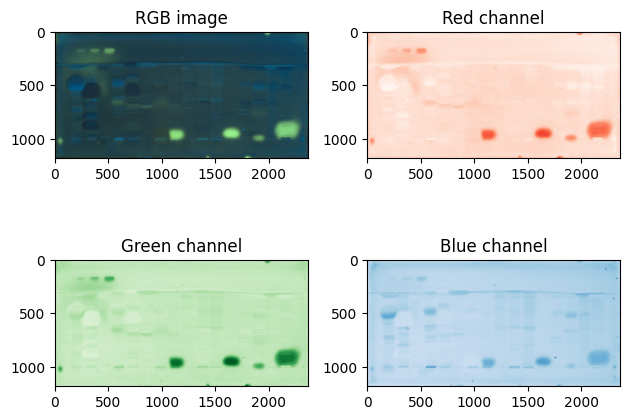

torch.Size([3, 1183, 2364])

In [2]:
from utils import load_image
img_tensor =load_image(path,  plot=True, return_gray_scale=False)
img_tensor.shape

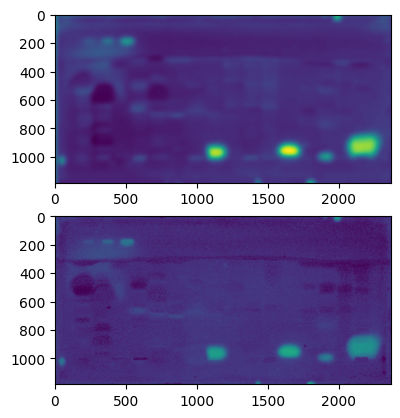

In [3]:
# cleaning the image
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter
from scipy.signal import medfilt

cleaned_image  = gaussian_filter(img_tensor, sigma=15)

fig, axes = plt.subplots(2,1)
axes[0].imshow(cleaned_image[0,:,:])
axes[1].imshow(img_tensor[0,:,:])


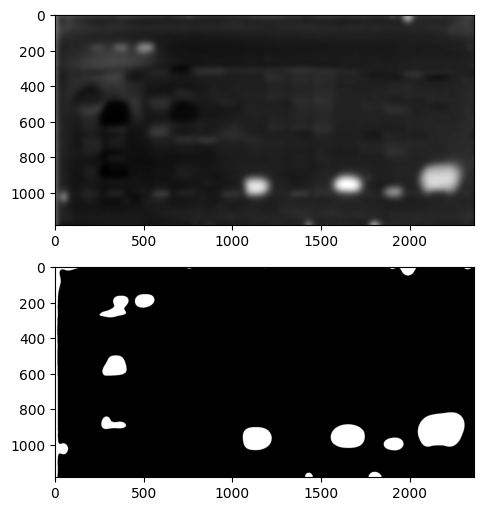

In [4]:
# making the masks
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
matrix=   cleaned_image[0,:,:]  # img_tensor[2,:,:]
flat_matrix = matrix.flatten()
background = stats.mode(flat_matrix, keepdims=False).mode

tolerance = 15                      # first parameter
lower_bound = background - tolerance
upper_bound = background + tolerance
mask = (matrix >= lower_bound) & (matrix <= upper_bound)

binary_mask = np.where(mask, 0, 255).astype(np.uint8)
inverted_mask = (~binary_mask).astype(np.uint8)
fig, axs = plt.subplots(2,1, figsize= (6,6))
axs[1].imshow(binary_mask, cmap="gray")
axs[0].imshow(matrix, cmap="gray")

plt.show()


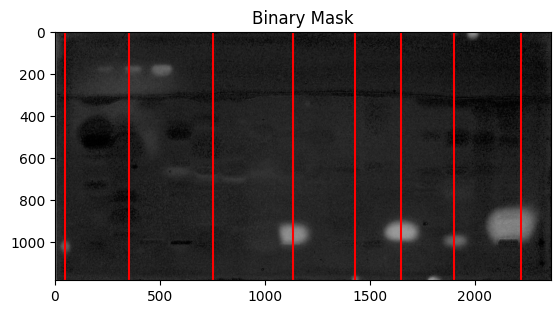

In [5]:
# making peaks with normal data
binary_mask_avg= torch.sum(torch.tensor(binary_mask), dim=0)/binary_mask.shape[0]
from scipy.signal import find_peaks

peaks, _ = find_peaks(binary_mask_avg, distance= 200 )    # second parameter

plt.imshow(img_tensor[0,:,:], cmap="gray")
for peak in peaks:
    plt.axvline(peak, color="red")
plt.title("Binary Mask")
plt.show()

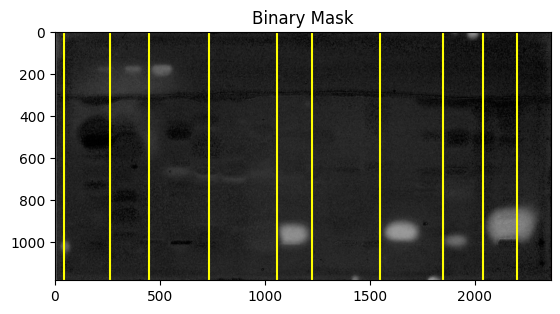

In [6]:
# checking with diff
import numpy as np

diff = np.diff(binary_mask_avg)
peaks_up, _ = find_peaks(diff, distance= 150 )   # second parameter

plt.imshow(img_tensor[0,:,:], cmap="gray")
for peak_up in zip(peaks_up):
    plt.axvline(peak_up, color="yellow")

plt.title("Binary Mask")
plt.show()

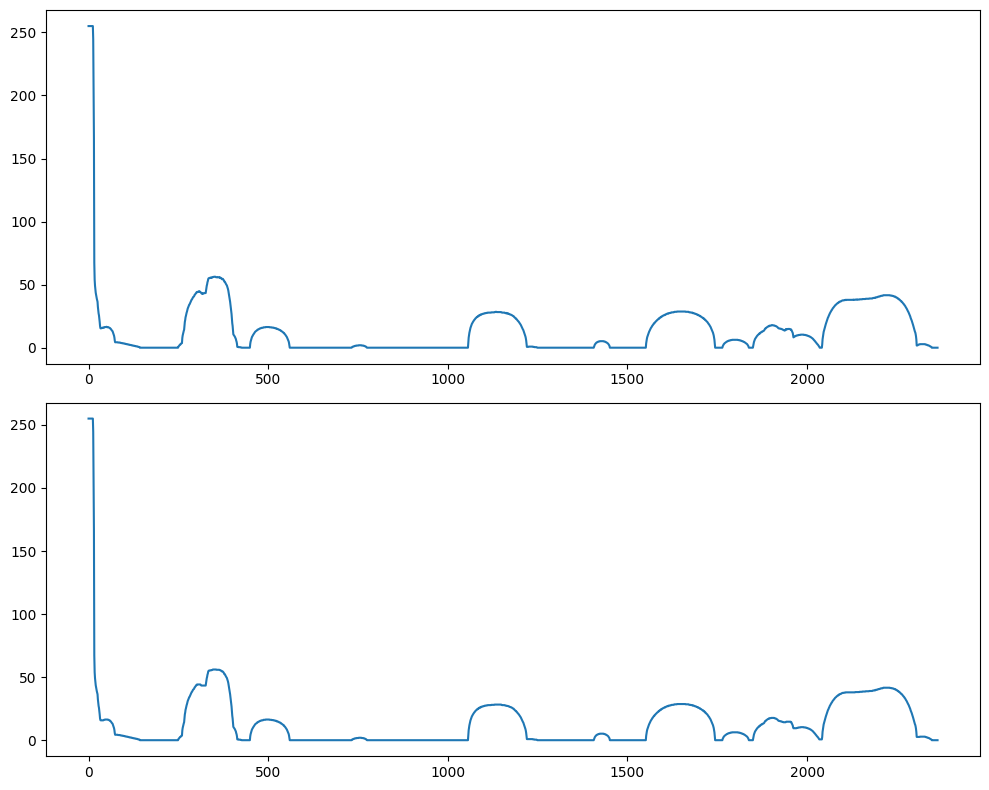

In [7]:
# smoothing the signal out
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d
from scipy.signal import medfilt

# smooth_binary_mask_avg = savgol_filter(binary_mask_avg, window_length = 150, polyorder=3)     # 3rd parameters
# smooth_binary_mask_avg = gaussian_filter1d(binary_mask_avg, sigma=15)  
smooth_binary_mask_avg = medfilt(binary_mask_avg, kernel_size=15)    # best 


fig, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].plot(binary_mask_avg, label='Original')
axs[1].plot(smooth_binary_mask_avg)
plt.tight_layout()
plt.show()


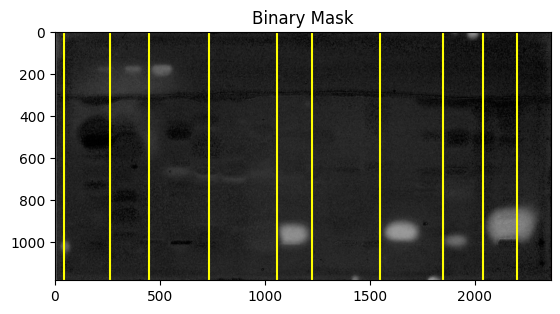

In [8]:
# plotting on the smooth signals.
diff = np.diff(smooth_binary_mask_avg)
peaks_up, _ = find_peaks(diff, distance= 150 )   # sencod parameter

plt.imshow(img_tensor[0,:,:], cmap="gray")
for peak_up in zip(peaks_up):
    plt.axvline(peak_up, color="yellow")

plt.title("Binary Mask")
plt.show()

NameError: name 'peaks_down' is not defined

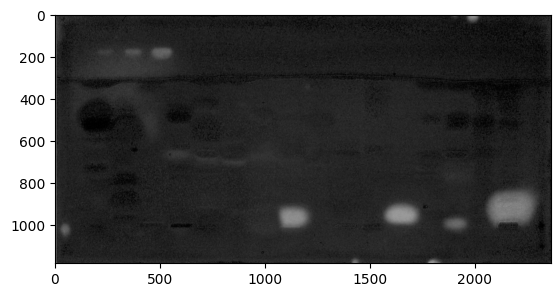

In [9]:
# modifying the values
peaks_up_updated = [peaks for peaks in peaks_up if 50<peaks and peaks<(len(binary_mask_avg)-100) ]    # rth paramters
plt.imshow(img_tensor[0,:,:], cmap="gray")
for peak_up, peak_down in zip(peaks_up_updated, peaks_down):
    plt.axvline(peak_up, color="yellow")
plt.title("Binary Mask")
plt.show()